In [12]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import xgboost
import lightgbm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_curve
import pickle

In [13]:
df=pd.read_csv("./Telecom Customers Churn.csv")

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.shape

(7043, 21)

## Data Cleaning

In [17]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### No missing values

In [19]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


### No duplicate values

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.drop(columns=['customerID'], inplace=True)

In [24]:
df.shape

(7043, 20)

In [25]:
def printuniquevalues(df):
    for i in df.columns:
        if df[i].dtype == "object":
            print(f'Unique values in {i}:', df[i].unique())

In [26]:
printuniquevalues(df)

Unique values in gender: ['Female' 'Male']
Unique values in Partner: ['Yes' 'No']
Unique values in Dependents: ['No' 'Yes']
Unique values in PhoneService: ['No' 'Yes']
Unique values in MultipleLines: ['No phone service' 'No' 'Yes']
Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in OnlineSecurity: ['No' 'Yes' 'No internet service']
Unique values in OnlineBackup: ['Yes' 'No' 'No internet service']
Unique values in DeviceProtection: ['No' 'Yes' 'No internet service']
Unique values in TechSupport: ['No' 'Yes' 'No internet service']
Unique values in StreamingTV: ['No' 'Yes' 'No internet service']
Unique values in StreamingMovies: ['No' 'Yes' 'No internet service']
Unique values in Contract: ['Month-to-month' 'One year' 'Two year']
Unique values in PaperlessBilling: ['Yes' 'No']
Unique values in PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Unique values in TotalCharges: ['29.85' '1889.5' '108.15' ... '34

### I see some issues in the above such as:
1. Unique values in MultipleLines: ['No phone service' 'No' 'Yes']- "No phone service" should be converted to "No"
2. Unique values in OnlineSecurity: ['No' 'Yes' 'No internet service']- "No internet service" should be converted to "No"
3. Unique values in OnlineBackup: ['Yes' 'No' 'No internet service']- "No internet service" should be converted to "No"
4. Unique values in DeviceProtection: ['No' 'Yes' 'No internet service']- "No internet service" should be converted to "No"
5. Unique values in TechSupport: ['No' 'Yes' 'No internet service']- "No internet service" should be converted to "No"
6. Unique values in StreamingTV: ['No' 'Yes' 'No internet service']- "No internet service" should be converted to "No"
7. Unique values in StreamingMovies: ['No' 'Yes' 'No internet service']- "No internet service" should be converted to "No"
8. Unique values in TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']- The data type should not be "object"

In [28]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
df['MultipleLines']=df['MultipleLines'].replace("No phone service", "No")

In [30]:
df['OnlineSecurity']=df['MultipleLines'].replace("No internet service", "No")
df['OnlineBackup']=df['OnlineBackup'].replace("No internet service", "No")
df['DeviceProtection']=df['DeviceProtection'].replace("No internet service", "No")
df['TechSupport']=df['TechSupport'].replace("No internet service", "No")
df['StreamingTV']=df['StreamingTV'].replace("No internet service", "No")
df['StreamingMovies']=df['StreamingMovies'].replace("No internet service", "No")

In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').astype('float64')

### Let's call the function again to see the number of unique values in object data types

In [33]:
printuniquevalues(df)

Unique values in gender: ['Female' 'Male']
Unique values in Partner: ['Yes' 'No']
Unique values in Dependents: ['No' 'Yes']
Unique values in PhoneService: ['No' 'Yes']
Unique values in MultipleLines: ['No' 'Yes']
Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in OnlineSecurity: ['No' 'Yes']
Unique values in OnlineBackup: ['Yes' 'No']
Unique values in DeviceProtection: ['No' 'Yes']
Unique values in TechSupport: ['No' 'Yes']
Unique values in StreamingTV: ['No' 'Yes']
Unique values in StreamingMovies: ['No' 'Yes']
Unique values in Contract: ['Month-to-month' 'One year' 'Two year']
Unique values in PaperlessBilling: ['Yes' 'No']
Unique values in PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Unique values in Churn: ['No' 'Yes']


In [34]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,No,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,No,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df['gender']=df['gender'].replace({"Male": 0, "Female": 1})

In [36]:
print("Unique values in InternetService:", df['InternetService'].unique())
print("Unique values in Contract:", df['Contract'].unique())
print("Unique values in PaymentMethod:", df['PaymentMethod'].unique())

Unique values in InternetService: ['DSL' 'Fiber optic' 'No']
Unique values in Contract: ['Month-to-month' 'One year' 'Two year']
Unique values in PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [37]:
df=pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

In [38]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,Yes,No,1,No,No,No,Yes,No,...,True,False,False,True,False,False,False,False,True,False
1,0,0,No,No,34,Yes,No,No,No,Yes,...,True,False,False,False,True,False,False,False,False,True
2,0,0,No,No,2,Yes,No,No,Yes,No,...,True,False,False,True,False,False,False,False,False,True
3,0,0,No,No,45,No,No,No,No,Yes,...,True,False,False,False,True,False,True,False,False,False
4,1,0,No,No,2,Yes,No,No,No,No,...,False,True,False,True,False,False,False,False,True,False


### Function to change values from object to int (0 and 1 for now)

In [40]:
cols=['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
for i in cols:
    df[i]=df[i].replace({"Yes": 1, "No": 0})

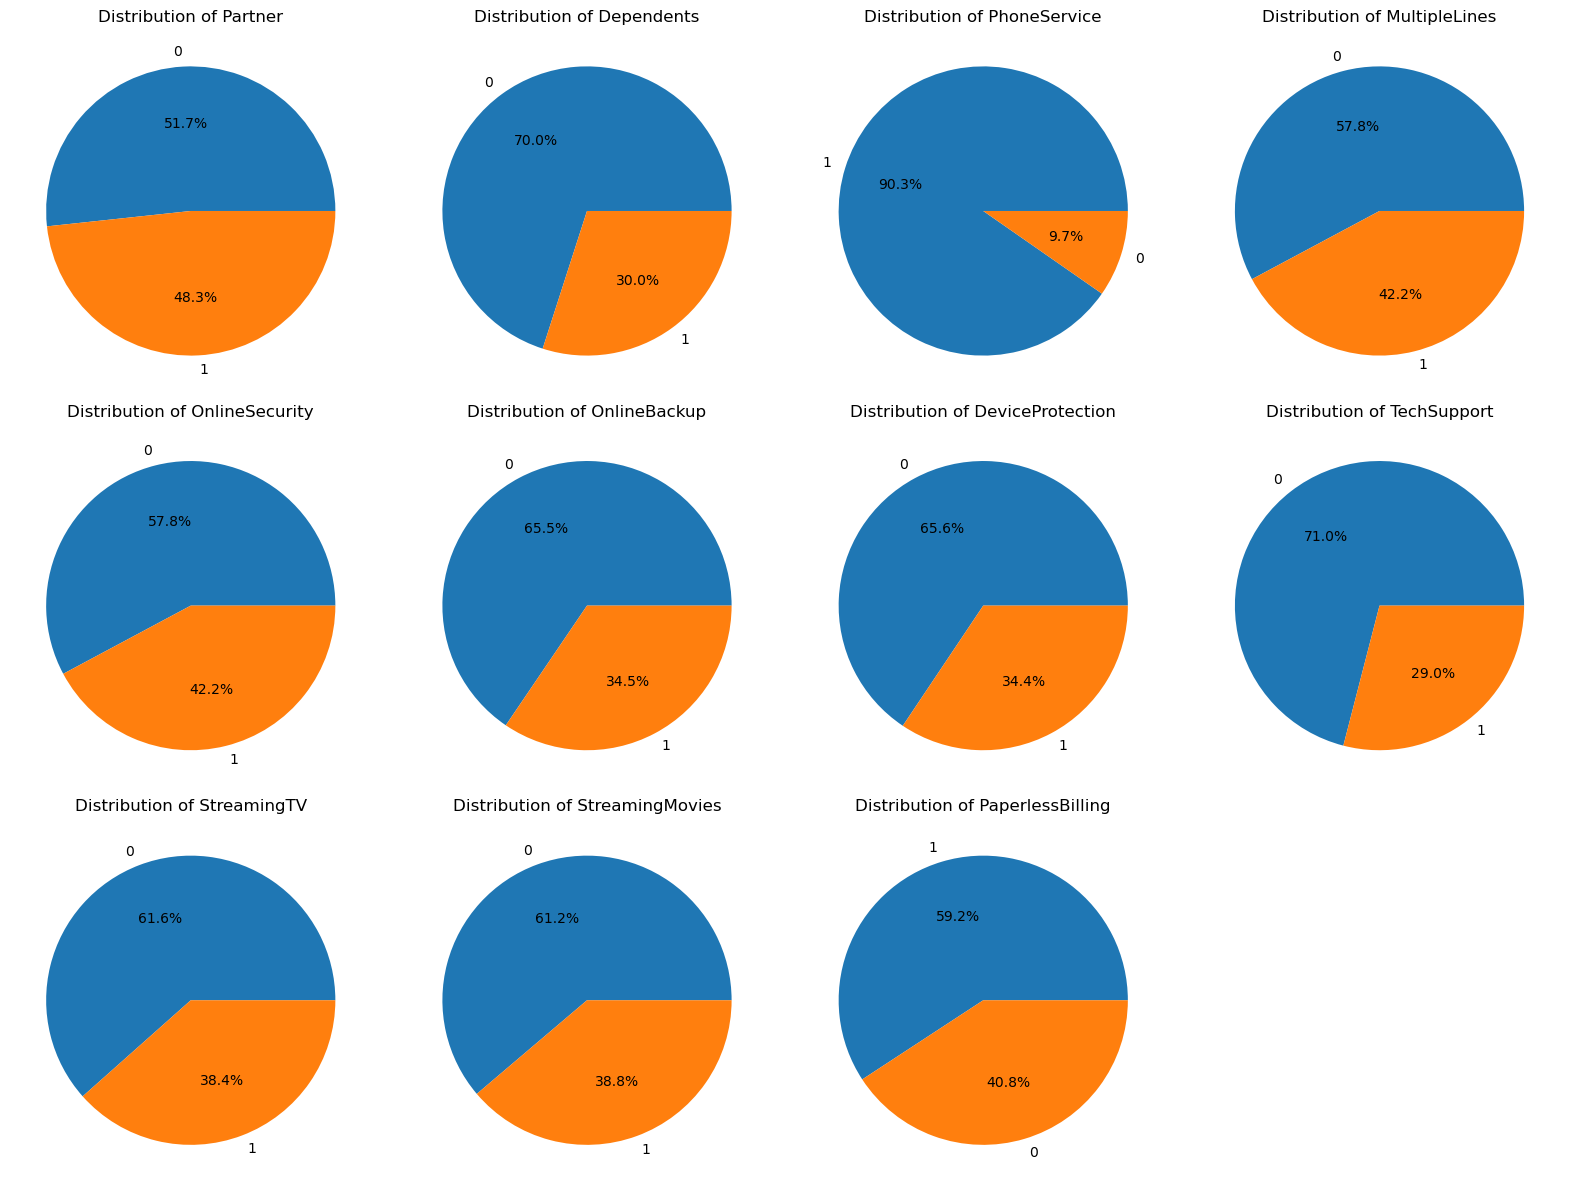

In [41]:
n_cols = 4
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, i in enumerate(cols):
    counts = df[i].value_counts()
    axes[idx].pie(counts, labels=counts.index, autopct='%1.1f%%')
    axes[idx].set_title(f'Distribution of {i}')

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [42]:
df_churn=df[df['Churn']=='Yes']

In [43]:
df_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2,0,0,0,0,2,1,0,0,1,0,...,True,False,False,True,False,False,False,False,False,True
4,1,0,0,0,2,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False
5,1,0,0,0,8,1,1,1,0,1,...,False,True,False,True,False,False,False,False,True,False
8,1,0,1,0,28,1,1,1,0,1,...,False,True,False,True,False,False,False,False,True,False
13,0,0,0,0,49,1,1,1,1,1,...,False,True,False,True,False,False,True,False,False,False


In [44]:
df_churn.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [45]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1869 entries, 2 to 7041
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   1869 non-null   int64  
 1   SeniorCitizen                            1869 non-null   int64  
 2   Partner                                  1869 non-null   int64  
 3   Dependents                               1869 non-null   int64  
 4   tenure                                   1869 non-null   int64  
 5   PhoneService                             1869 non-null   int64  
 6   MultipleLines                            1869 non-null   int64  
 7   OnlineSecurity                           1869 non-null   int64  
 8   OnlineBackup                             1869 non-null   int64  
 9   DeviceProtection                         1869 non-null   int64  
 10  TechSupport                              1869 non-nul

In [46]:
churn_cols=df_churn.columns
churn_cols=churn_cols.drop(["MonthlyCharges", 'TotalCharges', 'tenure', 'Churn'])
print(len(churn_cols))

23


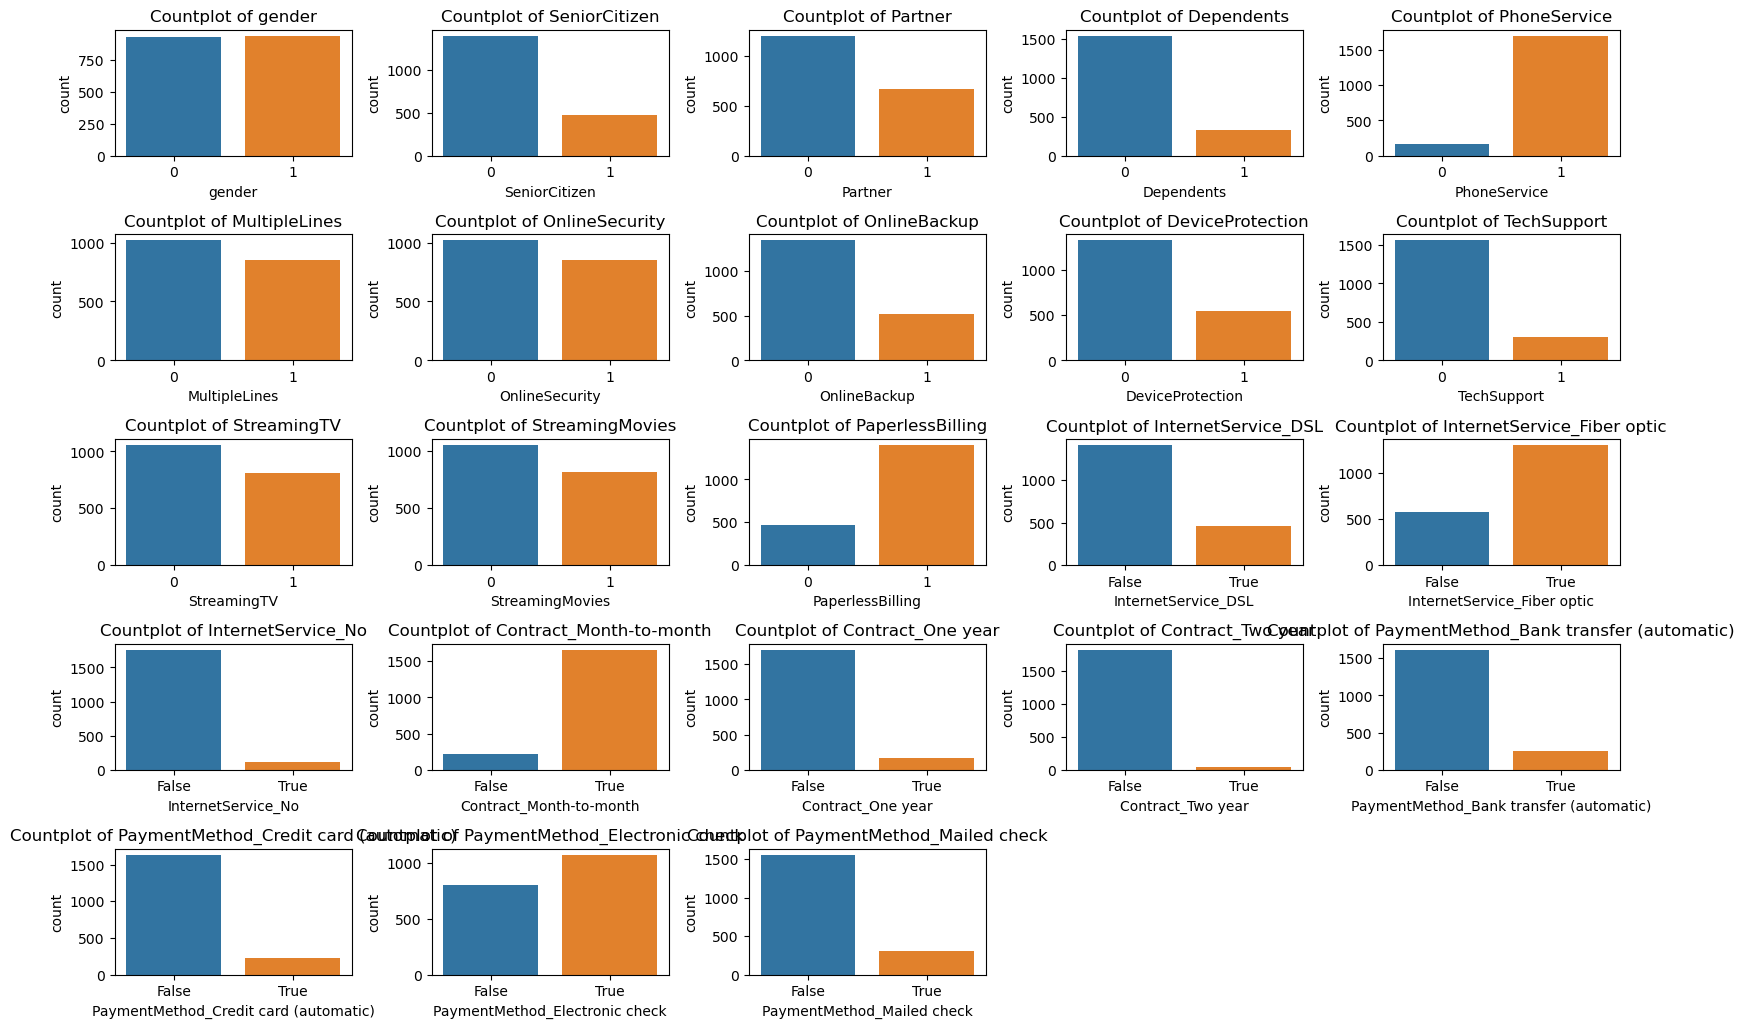

In [47]:
n_rows=6
n_cols=5
fig, axes=plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes=axes.flatten()

for idx, i in enumerate(churn_cols):
    sns.countplot(x=df_churn[i], ax=axes[idx])
    axes[idx].set_title(f"Countplot of {i}")

for j in range(len(churn_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Based on the graphs/visuals above the insight is that the customers were not in the ecosystem and probably that's why we see the churn.. For example, no internet service, a lot of people for the month-to-month contract and a very few had a one-year/two-year contract etc
                                                                                                                            

In [49]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,0,0,1,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,0,0,1,0,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,0,0,1,...,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False


### Now, let's convert all the True values to 1 and False to 0

In [51]:
df=df.replace({True: 1, False: 0})

In [52]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,0,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,0,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [53]:
df=df.replace({"Yes": 1, "No": 0})

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

In [55]:
df.isna().sum()

gender                                      0
SeniorCitizen                               0
Partner                                     0
Dependents                                  0
tenure                                      0
PhoneService                                0
MultipleLines                               0
OnlineSecurity                              0
OnlineBackup                                0
DeviceProtection                            0
TechSupport                                 0
StreamingTV                                 0
StreamingMovies                             0
PaperlessBilling                            0
MonthlyCharges                              0
TotalCharges                               11
Churn                                       0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
Contract_Month-to-month                     0
Contract_One year                 

In [56]:
df.dropna(inplace=True)

### Now every column is either float or int, so we can begin with the modeling part. Let's start with the baseline model- Logistic Regression

In [58]:
X=df.drop(columns=['Churn'])
y=df['Churn']

In [59]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)

In [60]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 26)
X_test shape: (1407, 26)
y_train shape: (5625,)
y_test shape: (1407,)


In [61]:
log_model=LogisticRegression()

In [62]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [63]:
log_pred=log_model.predict(X_test)

In [64]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1044
           1       0.63      0.55      0.58       363

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



### Insights: Model is biased towards class 0 (non-churn)

In [66]:
#Tells the model to care more about the minority classes
log_model1=LogisticRegression(class_weight='balanced')

In [67]:
log_model1.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [68]:
log_pred1=log_model1.predict(X_test)

In [69]:
print(classification_report(y_test, log_pred1))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1044
           1       0.50      0.79      0.61       363

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



In [70]:
log_reg_scores=log_model1.predict_proba(X_test)[:, 1]

In [71]:
fpr, tpr, thresholds=roc_curve(y_test, log_reg_scores)

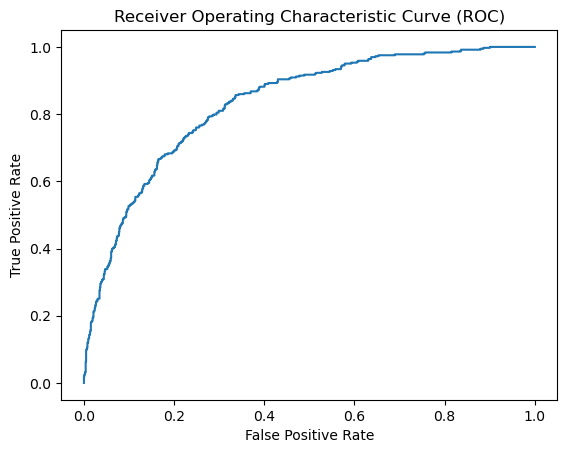

In [72]:
plt.plot(fpr, tpr)
plt.title("Receiver Operating Characteristic Curve (ROC)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [73]:
optimal_idx=np.argmax(tpr-fpr)
optimal_threshold=thresholds[optimal_idx]
print("Optimal threshold value for Logistic Regression:", optimal_threshold)

Optimal threshold value for Logistic Regression: 0.42620196030227653


In [74]:
log_reg_pred_adjusted=(log_reg_scores>=optimal_threshold).astype(int)

In [75]:
print(classification_report(y_test, log_reg_pred_adjusted))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1044
           1       0.47      0.86      0.61       363

    accuracy                           0.71      1407
   macro avg       0.70      0.76      0.69      1407
weighted avg       0.81      0.71      0.73      1407



In [76]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,0,34,1,0,0,0,1,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,0,2,1,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,0,45,0,0,0,0,1,...,1,0,0,0,1,0,1,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0


In [77]:
rf_model=RandomForestClassifier()

In [78]:
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [79]:
rf_pred=rf_model.predict(X_test)

In [80]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1044
           1       0.64      0.50      0.56       363

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407



In [81]:
xgb_model=XGBClassifier()

In [82]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [83]:
xgb_pred=xgb_model.predict(X_test)

In [84]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1044
           1       0.60      0.55      0.57       363

    accuracy                           0.79      1407
   macro avg       0.72      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [85]:
print("Length of y_train==0:", len(y_train[y_train==0]))
print("Length of y_train==1:", len(y_train[y_train==1]))
scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1])
print("Scale pos weight:", scale_pos_weight)

Length of y_train==0: 4119
Length of y_train==1: 1506
Scale pos weight: 2.735059760956175


### The model gives 2.75x more attention to the minority class during training

In [87]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model1 = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

In [88]:
xgb_model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [89]:
xgb_pred1=xgb_model1.predict(X_test)

In [90]:
print(classification_report(y_test, xgb_pred1))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1044
           1       0.51      0.81      0.63       363

    accuracy                           0.75      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



In [91]:
lgb_model=LGBMClassifier(class_weight='balanced')

In [92]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1506, number of negative: 4119
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 629
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced')

In [93]:
lgb_pred=lgb_model.predict(X_test)

In [94]:
print(classification_report(y_test, lgb_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1044
           1       0.52      0.74      0.61       363

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407



### Now, let's take it to the prod

In [96]:
with open("xgb_model1.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [97]:
xgb_model.save_model("xgb_model.json")

In [98]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("lightgbm:", lightgbm.__version__)

pandas: 2.2.3
numpy: 1.26.4
matplotlib: 3.7.1
seaborn: 0.12.2
scikit-learn: 1.3.0
xgboost: 2.0.3
lightgbm: 4.6.0


In [99]:
import fastapi, uvicorn

print("fastapi:", fastapi.__version__)
print("uvicorn:", uvicorn.__version__)

fastapi: 0.115.12
uvicorn: 0.27.0
